<a href="https://colab.research.google.com/github/wjarret/Thesis_Code_Book/blob/main/snRNA%20data%20analysis/Sliding_window_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Overview

Scientific question: Given the variance seen in previous U snRNA data, can we isolate the U snRNA data from other sequences?

Samples: All U snRNA sequencing data to date.

Expeirmental design: To set up this eperiment, I will be isolating all possible 16 nt combinations of snRNA data by creating a sliding window.

Expected outcome:  This experiment will group together all U snRNA data, proving that the Sm binding region is unique and identifiable in a larger dataset.

In this document, I will be creating a dataset consisting of 16 nucleotide chunks of snRNA RNP-MaP data. To do this, starting at the begining of every seqeunce, for every 16 nucloetides, create its own data frame consisting of all RNP-MaP data, labeled with a unique name. After each window is created, dimensionality reduction will be used to assess variation. Steps:

> Create function that uses a sliding window to get all possible 16 window combinations and label each one based off of seqeunce identity.
>
> Apply function across all datasets.
>
> Run Principle Component Analysis (PCA) on all data and define inclusive principle components
>
> Due to increased data complexity, Uniform Manifold Approximation and Projection (UMAP) will be used.


###Loading in Librarys

In [ ]:
#Librarys
import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from google.colab import data_table
data_table.enable_dataframe_formatter()
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
# import itables
# from itables import init_notebook_mode
# init_notebook_mode()

#Directory
PATH = '/content/drive/My Drive/Data/RNP_MaP_CSVs'
os.chdir(PATH)
os.listdir()

Mounted at /content/drive


['HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv',
 'HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv',
 'HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa

In [ ]:
# !pip install black[jupyter]
# !black /content/drive/MyDrive/Colab\ Code/04092026_creating_sliding_window.ipynb


### Loading in snRNA Data Frames

In [ ]:
#20260129
U1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U4_1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv')
U4_2_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv')
U4_atac_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U5A_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv')
U5B_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv')
#07/07/2025
U1_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
#05/05/2025
U1_DMSO_aq_SDA_int_20250525 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv')
#11/09/24
U1_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')

print(len(U11_DMSO_aq_SDA_int_11092024))

#Data Dictionary

D_D = {
    'U1.1':  U1_DMSO_aq_SDA_int_11092024,
    'U1.2':  U1_DMSO_aq_SDA_int_20250525,
    'U1.3':  U1_DMSO_aq_SDA_int_20250707,
    'U1.4':  U1_DMSO_aq_SDA_int_20260129,
    'U2.1':  U2_DMSO_aq_SDA_int_11092024,
    'U2.2':  U2_DMSO_aq_SDA_int_20250707,
    'U11.1': U11_DMSO_aq_SDA_int_11092024,
    'U11.2': U11_DMSO_aq_SDA_int_20250707,
    'U11.3': U11_DMSO_aq_SDA_int_20260129,
    'U12.1': U12_DMSO_aq_SDA_int_11092024,
    'U12.2': U12_DMSO_aq_SDA_int_20250707,
    'U12.3': U12_DMSO_aq_SDA_int_20260129,
    'U4-1': U4_1_DMSO_aq_SDA_int_20260129,
    'U4-2': U4_2_DMSO_aq_SDA_int_20260129,
    'U4atac': U4_atac_DMSO_aq_SDA_int_20260129,
    'U5A': U5A_DMSO_aq_SDA_int_20260129,
    'U5B': U5B_DMSO_aq_SDA_int_20260129
}



128


### Creating Function

In [ ]:
def sliding_window(data,window_size,step):
  d = {}
  for key, df in data.items():
    n = len(df)
    for i in range(0,n-window_size+1,step):
      window = df.iloc[i:window_size+i].reset_index(drop=True)
      identity = f'{key}_{i}:{window_size+i}'
      d[identity] = window
  return d


In [ ]:
window = sliding_window(D_D,24,1)

#This  is used to isolate the Norm_Score from each dataframe in the list. The new list is then concatenated into a single dataframe for PCA.
d = {}
for key, df in window.items():
    df = df[['Norm_Score']]
    identifier = f'{key}'
    d[identifier] = df
PCA_dataframe = pd.concat(d)
PCA_dataframe = PCA_dataframe.reset_index()  # Assign the result back to PCA_dataframe

# PCA_dataframe_edit = PCA_dataframe[['level_0','Norm_Score']]
# PCA_dataframe_edit = PCA_dataframe_edit.set_index('level_0')
#pca_matrix.head(25)

###PCA Analysis

Because RNP data has been normalized prior to the PCA, we have decided to not divide by the standard deviation during the scaling step but to only subtract the mean so PCA only captures the variance of the data rather than where the data lives in space.

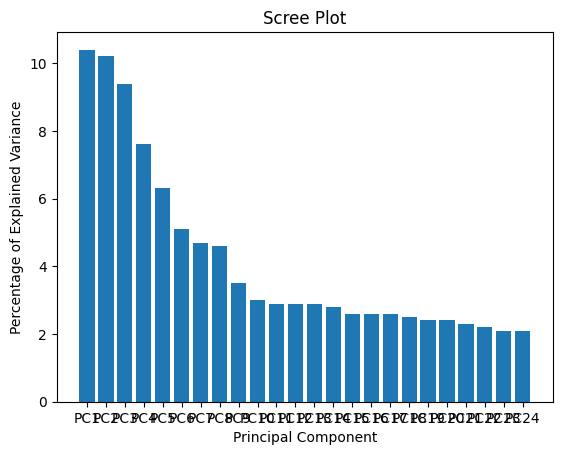

level_1,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
level_0,,,,,,,,,,,,,,,,,,,,,
U1.1_0:24,0.000000,0.000000,0.000000,1.020287,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.299090,0.000000,0.344529,0.515930,0.002606,0.008840,1.490299,0.081529,0.036184,0.463902
U1.1_100:124,0.094817,0.317648,0.935329,0.971526,1.177496,0.000000,1.393031,0.000000,0.000000,0.238452,...,0.089957,0.000000,1.940482,1.536145,0.121293,0.000000,0.220139,0.000000,0.203880,1.508289
U1.1_101:125,0.317648,0.935329,0.971526,1.177496,0.000000,1.393031,0.000000,0.000000,0.238452,0.134776,...,0.000000,1.940482,1.536145,0.121293,0.000000,0.220139,0.000000,0.203880,1.508289,0.419833
U1.1_102:126,0.935329,0.971526,1.177496,0.000000,1.393031,0.000000,0.000000,0.238452,0.134776,0.000000,...,1.940482,1.536145,0.121293,0.000000,0.220139,0.000000,0.203880,1.508289,0.419833,0.271496
U1.1_103:127,0.971526,1.177496,0.000000,1.393031,0.000000,0.000000,0.238452,0.134776,0.000000,0.000000,...,1.536145,0.121293,0.000000,0.220139,0.000000,0.203880,1.508289,0.419833,0.271496,0.305478


In [ ]:
#PCA
pca_matrix = PCA_dataframe.pivot(index='level_0',columns = 'level_1',values ='Norm_Score')
pca_matrix = pca_matrix.fillna(0)
# scaling = StandardScaler(with_mean=True, with_std=False)
scaled_pca_matrix = StandardScaler(with_mean=True, with_std=False).fit_transform(pca_matrix)
pca = PCA()
pca.fit(scaled_pca_matrix)
pca_scores = pca.fit_transform(scaled_pca_matrix)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()
pca_matrix.head()

Text(0, 0.5, 'Cumulative Explained Variance')

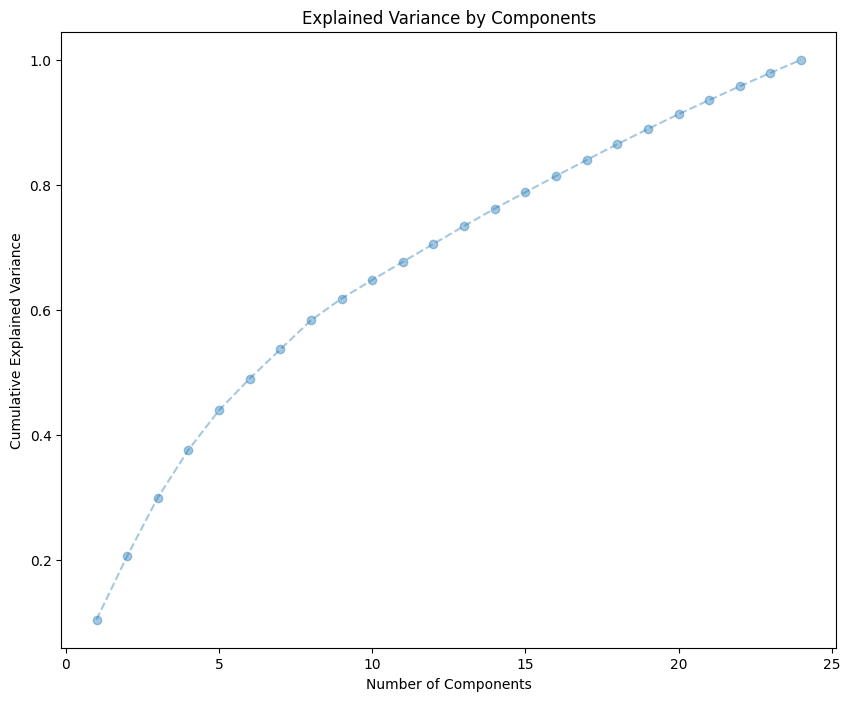

In [ ]:
plt.figure( figsize = (10,8))
plt.plot(range(1,len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--', alpha=0.4)
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

From this plot, I will be using the first 20 principle components

##PCA scatter plot is no longer applicable

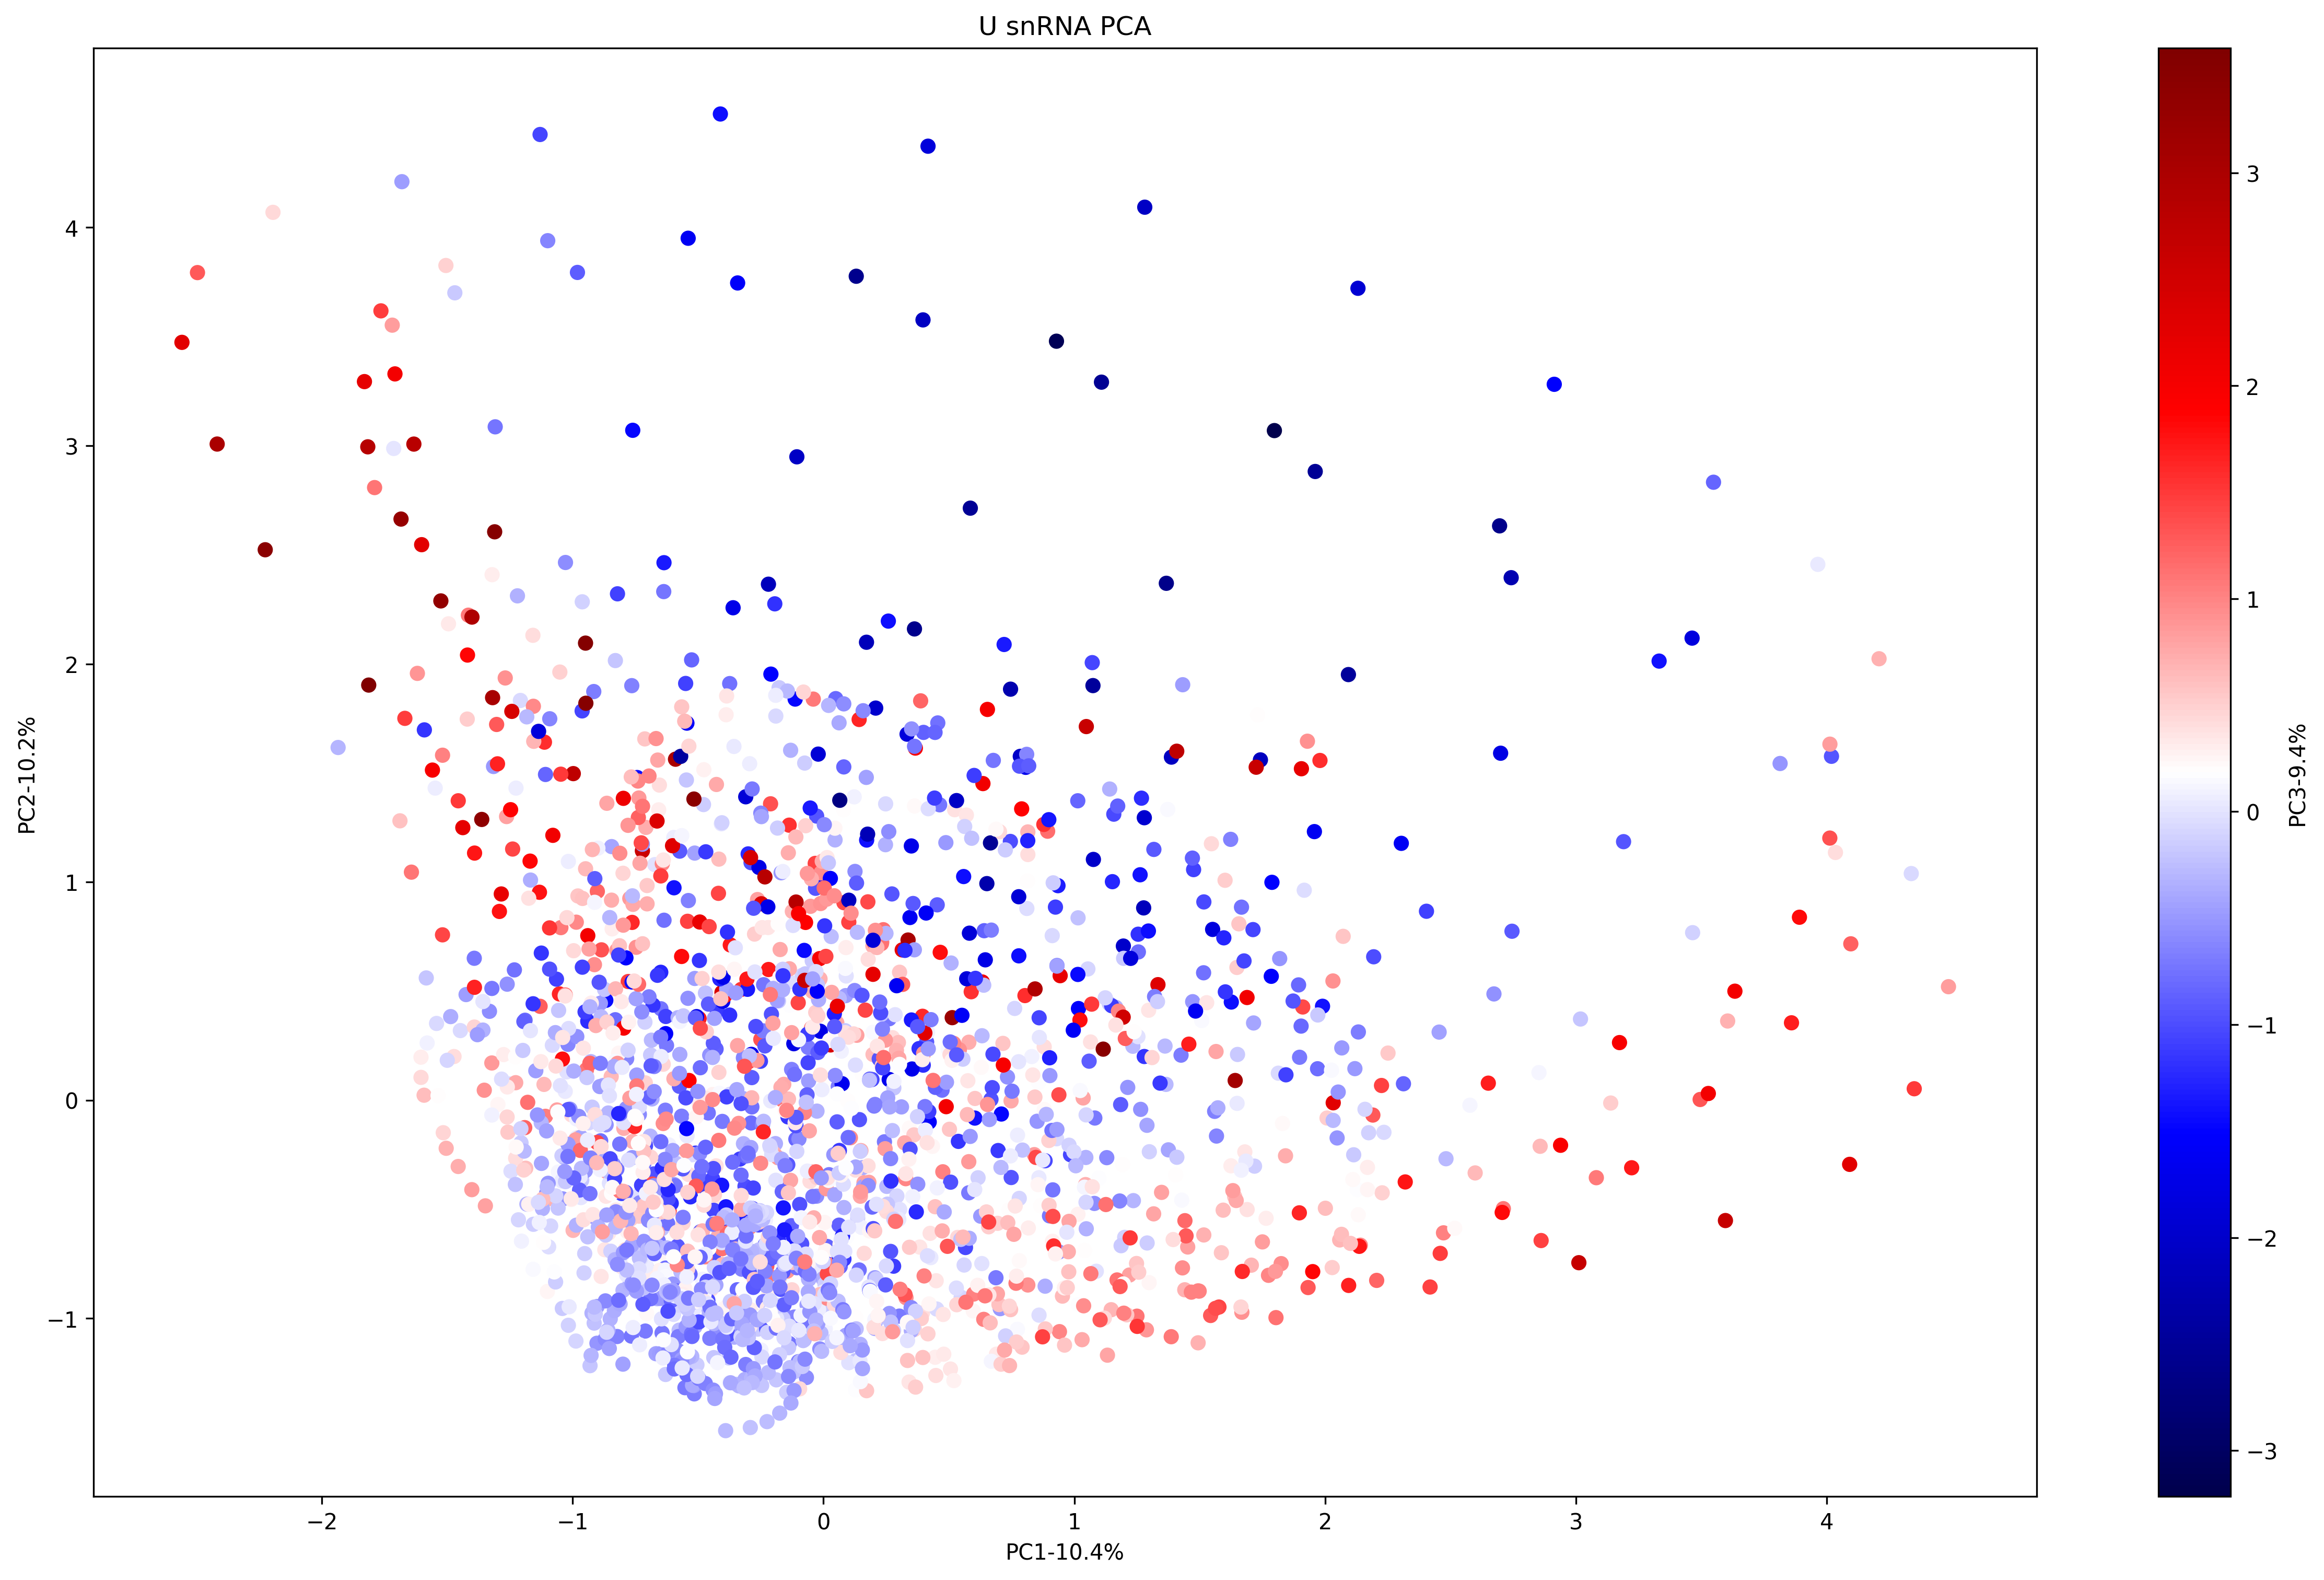

In [ ]:
pca_df = pd.DataFrame(pca_scores, index=pca_matrix.index,
                      columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
#pca_df = pd.DataFraåme(pca_data, columns=labels)
pca_df.head()
plt.figure(figsize=(20, 12), dpi=300)

plt.title('U snRNA PCA')

scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['PC3'], cmap= 'seismic')
plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC2-{0}%'.format(per_var[1]))
plt.colorbar(scatter, label='PC3-{0}%'.format(per_var[2]))

# for sample in pca_df.index:
#   plt.annotate(sample, (pca_df['PC1'][sample], pca_df['PC2'][sample]))#, xytext=(15, 15))
#   textcoords='offset points',
#   arrowprops=dict(arrowstyle='->')
#plt.savefig('snRNA_PCA_03162026.png', dpi=300)
plt.show()

In [ ]:
pca_df.shape

(2115, 24)

Looking at the scree plot, the majority of the variance is not explained in the first two principle components. When this is the case, the data is viewed as highly complex. To deal with this, I will be using Uniform Manifold Approximaiton and Projection (UMAP). When considering other techniques, t-SNE is the other options, t-SNE could also be used. Because of its reduced speed, reduced interpretability, and being computationally expensive, UMAP sets out to be a better option.

https://pair-code.github.io/understanding-umap/

As data beomes more complex (i.e. the majority of the variance isn't eplained by the first two principle components as a result of increased number objects not features) other dimmensionality reuction techniques are used. For our case we are using UMAP. UMAP calculates similarity scores of both high dimensional and low dimmensional data in order cluster points together on a graph based on their specified nearest neighbors. It is important to note that the disance of each cluster on the graph is meaningless and the spread of daata within each cluster is also meaningless. UMAP tells us the objects that group together or are seperated based on their features. PCA is typically used with UMAP to help reduce noise.

Documentation: https://umap-learn.readthedocs.io/en/latest/parameters.html

---



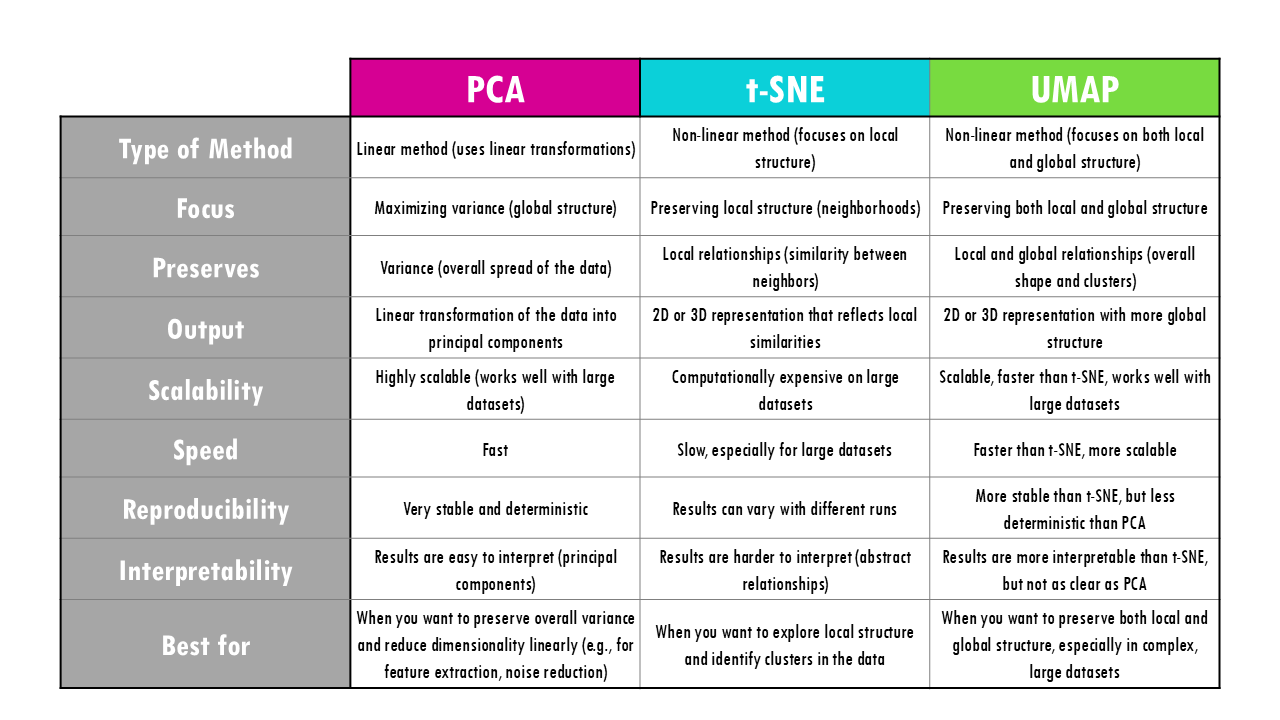

#UMAP Code

In [ ]:
from numpy.random import RandomState
import umap
import matplotlib.pyplot as plt
import plotly.express as px

#Define PCs to be used (50 PCs encompasses 90 percent of total variance)
def draw_umap(data,n_neighbors, pca_Components, n_components, metric,random_state, labeling, title='', points_to_label=None):
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        metric=metric,
        random_state=random_state
    )
    pca_umap = PCA(n_components=pca_Components)
    u = fit.fit_transform(data)
    # Generate text array: only show text if the label is in points_to_label
    text_labels = [lbl if points_to_label and lbl in points_to_label else "" for lbl in labeling]

    if n_components == 1:
        fig = plt.figure()
        plt.title(title, fontsize=18)
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], range(len(u)))
        plt.show()
    if n_components == 2:
        fig = plt.figure()
        plt.title(title, fontsize=18)
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], u[:,1])
        plt.show()
    if n_components == 3:
        fig3d = px.scatter_3d(data_frame=u, x=0, y=1, z=2,hover_data=[labeling],
        # color=sample_colors,
        text=text_labels,
        # labels={0: 'PC1-{0}%'.format(per_var[0]),
        #           1: 'PC2-{0}%'.format(per_var[1]),
        #           2: 'PC3-{0}%'.format(per_var[2])},
        title=title
                      )
        # Update traces to format the text specifically
        fig3d.update_traces(textposition='top center', textfont=dict(size=10, color='black'))
        return fig3d

# pca_umap = PCA(n_components=50)
# fit = umap.UMAP()
# u = fit.fit_transform(scaled_pca_matrix)
label= pca_matrix.index

# function to highlight points
points_to_highlight = [
    'U1.1_118:142', 'U1.2_118:142', 'U1.3_118:142', 'U1.4_114:138',
    'U2.1_90:114', 'U2.2_90:114',
    'U11.1_80:104', 'U11.2_80:104', 'U11.3_78:102',
    'U12.1_66:90', 'U12.2_66:90', 'U12.3_64:88',
    'U4-1_110:134', 'U4-2_110:134', 'U4atac_97:121',
    'U5A_80:104', 'U5B_80:104'
]

x = draw_umap(scaled_pca_matrix,n_neighbors=20,pca_Components=20,n_components=3,metric = 'euclidean',random_state=5,labeling=label,title = 'n_neighbors = 16', points_to_label=points_to_highlight)
x.show()

#HTML export
# output_html_file = 'Sliding window.html'
# x.write_html(output_html_file)
# print(f"Interactive 3D PCA plot saved to {output_html_file}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


###**Results**:
> UMAP data shows that the Sm-sites are not seperable from non-Sm sites.



### **Discussion**

> The aim of this experiment was to analyze whether RNP-MaP reactivity profiles of Sm-binding sites are separable from non-Sm sites. Windowed Norm_Score profiles were generated across snRNA sequences, with windows classified as either Sm-binding or non-Sm (background) sites. Principal Component Analysis (PCA) was performed to assess variance structure; the scree plot showed that most variance is not captured in the first three PCs, motivating nonlinear dimensionality reduction. Uniform Manifold Approximation and Projection (UMAP) was applied to visualize potential clustering. Results show that Sm and non-Sm sites are intermixed in the UMAP embedding, with Sm-binding profiles not forming a visually distinct cluster. This intermixing suggests that distinguishing features of Sm binding are either subtle or context-dependent, varying with position within the snRNA or surrounding nucleotide sequence. However, visual intermixing in 2D projection does not mean there is no high-dimensional structure that a machine learning classifier couldn't detect. The nezt steps will use variance analysis to have statisical tests to substantiate these findings.

###Future Direction
> Use a MANOVA/Wilks Lambda or a nonparametric Multivariate Kruskal-Wallis (MKW) test  to verify what we see from the UMAP data. Identify other methods that could potentially identify high dimensional structure within the data.